# Avance 2. Ingeniería de características (Feature Engineering)

**Sistema Inteligente para la Optimización de Operaciones de Transporte mediante Inteligencia Artificial aplicada al Análisis Predictivo de Datos GPS**

Maestría en Inteligencia Artificial Aplicada, TC5035 — Equipo 56

**Equipo**
- Alejandra Guadalupe Larrañaga Altamirano, A01794334
- Mario Alberto Guillén De La Torre, A01796701
- Andrea Kimberly Fray Tamayo, A01797168

**Fecha:** 11 de octubre de 2026

---

## Objetivo de esta fase

Este notebook continúa directamente el Avance 1. Se parte de `../data/processed/trips_clean.csv`, donde ya se realizaron la limpieza, tratamiento de faltantes, reglas de atípicos y codificación básica.

En esta fase se realiza ingeniería de características, seguida de selección mediante métodos de filtrado.

**Variable objetivo:** `duration_seconds`, problema de regresión.

> Importante: no se utilizan como variables predictoras `ended_at`, `duration_seconds`, `average_speed`, `max_speed`, `stops_count` ni `stopped_seconds`, porque son información posterior o resultado del viaje. Tampoco se usa `data_source`, ya que identifica nuestro pipeline de datos y no una característica disponible en producción.


## 1. Carga y revisión del dataset del Avance 1

El Avance 1 ya produjo el dataset limpio. Aqui no se repiten las etapas de limpieza, unicamente se verifica que las columnas necesarias esten disponibles y que la variable objetivo sea continua

In [4]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

#from google.colab import drive
#drive.mount('/content/drive')

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

IN_COLAB = "google.colab" in sys.modules

#CLEAN_PATH = "/content/drive/My Drive/Protocolos de comunicacion vehicular/transport-gps-analytics-main/data/processed/trips_clean.csv"
CLEAN_PATH = "../data/processed/trips_clean.csv"

if os.path.exists(CLEAN_PATH):
    df = pd.read_csv(CLEAN_PATH)
elif IN_COLAB:
    print(f"No se encontró '{CLEAN_PATH}'. Sube el archivo manualmente:")
    from google.colab import files
    uploaded = files.upload()
    fname = list(uploaded.keys())[0]
    df = pd.read_csv(fname)
else:
    raise FileNotFoundError(
        f"No se encontró {CLEAN_PATH}. "
        f"Ejecuta este notebook desde la carpeta notebooks/ del repositorio."
    )

print("Dimensiones:", df.shape)
print("Columnas:")
print(df.columns.tolist())
display(df.head())


No se encontró '../data/processed/trips_clean.csv'. Sube el archivo manualmente:


Saving trips_clean.csv to trips_clean (2).csv
Dimensiones: (436807, 19)
Columnas:
['vehicle_id', 'started_at', 'ended_at', 'duration_seconds', 'distance_km', 'average_speed', 'max_speed', 'stops_count', 'stopped_seconds', 'data_source', 'origin_zone', 'destination_zone', 'origin_zone_id', 'destination_zone_id', 'corridor', 'hour_of_day', 'day_of_week', 'previous_trip_duration', 'historical_corridor_mean_duration']


/tmp/ipykernel_2634/2428112870.py:30: DtypeWarning: Columns (10,11,14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(fname)


,vehicle_id,started_at,ended_at,duration_seconds,distance_km,average_speed,max_speed,stops_count,stopped_seconds,data_source,origin_zone,destination_zone,origin_zone_id,destination_zone_id,corridor,hour_of_day,day_of_week,previous_trip_duration,historical_corridor_mean_duration
0,1,2026-09-25 16:29:37+00:00,2026-09-25 16:38:38+00:00,541,2.643,17.312506,43.000016,0.0,0.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,11,4,3857.0,3932.083333
1,1,2026-09-25 18:24:35+00:00,2026-09-25 19:38:06+00:00,4411,7.208,13.770786,52.000019,5.0,802.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,13,4,541.0,541.000000
2,1,2026-09-25 20:01:18+00:00,2026-09-25 22:08:06+00:00,7608,19.750,23.562359,70.000025,13.0,1054.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,15,4,4411.0,2476.000000
3,1,2026-09-27 19:44:05+00:00,2026-09-27 20:22:57+00:00,2332,4.674,16.452921,54.000020,5.0,233.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,14,6,7608.0,4186.666667
4,1,2026-09-28 15:05:32+00:00,2026-09-28 16:56:24+00:00,6652,9.370,15.320394,49.000018,3.0,337.0,real,Cancun,Cancun,NaN,NaN,Cancun → Cancun,10,0,2332.0,3723.000000


## 2. Definición de la variable objetivo y separación entrenamiento/prueba

Como el objetivo es predecir la duracion de un viaje, `duration_seconds` se mantiene unicamente como target. La separacion se realiza antes de ajustar transformaciones que aprendan estadisticas de los datos.

Se utiliza una separacion temporal aproximada: los primeros 80% de viajes ordenados por `started_at` forman entrenamiento y el 20% final prueba.

In [5]:
TARGET = "duration_seconds"

excluded = [
    TARGET, "ended_at", "average_speed", "max_speed",
    "stops_count", "stopped_seconds", "data_source"
]

df = df.sort_values("started_at").reset_index(drop=True)

split_idx = int(len(df) * 0.80)
train_raw = df.iloc[:split_idx].copy()
test_raw = df.iloc[split_idx:].copy()

print(f"Train: {train_raw.shape}")
print(f"Test : {test_raw.shape}")
print(f"Periodo train: {train_raw['started_at'].min()} -> {train_raw['started_at'].max()}")
print(f"Periodo test : {test_raw['started_at'].min()} -> {test_raw['started_at'].max()}")


Train: (349445, 19)
Test : (87362, 19)
Periodo train: 2026-09-25 16:29:37+00:00 -> 2026-10-27 14:00:00+00:00
Periodo test : 2026-10-27 14:00:00+00:00 -> 2026-11-02 04:00:00+00:00


## 3. Generación de nuevas características

Se generan variables que representan patrones relevantes para el problema de transporte:

1. **Características cíclicas del tiempo:** `hour_sin`, `hour_cos`, `dow_sin`, `dow_cos`. La hora 23 y la hora 0 son cercanas, aunque numéricamente esten separadas.
2. **Fin de semana:** `is_weekend`, util para representar cambios de operacion entre dias laborales y fin de semana.
3. **Horario de mayor demanda:** `is_rush_hour`, usando una regla de dominio (07–09 y 16–18).
4. **Transformación logaritmica de distancia:** `distance_log1p`. Se incluye como alternativa a `distance_km` para representar posibles relaciones no lineales. No se transforma la variable objetivo, porque en el Avance 1 se observo que `log(duration_seconds + 1)` empeoraba la forma de la distribución.
5. **Binning de distancia:** `distance_bin`. Se calculan los puntos de corte con cuantiles del conjunto de entrenamiento y se aplican sin volver a estimarlos en prueba. Esto permite representar efectos no lineales por rangos de distancia.

No se generan variables a partir de `duration_seconds` ni de informacin posterior al inicio del viaje.

In [6]:
def add_features(data, distance_bins=None):
    out = data.copy()

    # Tiempo ciclico
    out["hour_sin"] = np.sin(2 * np.pi * out["hour_of_day"] / 24)
    out["hour_cos"] = np.cos(2 * np.pi * out["hour_of_day"] / 24)
    out["dow_sin"] = np.sin(2 * np.pi * out["day_of_week"] / 7)
    out["dow_cos"] = np.cos(2 * np.pi * out["day_of_week"] / 7)

    # Indicadores de calendario/operacion
    out["is_weekend"] = (out["day_of_week"] >= 5).astype("int8")
    out["is_rush_hour"] = (
        out["hour_of_day"].between(7, 9) |
        out["hour_of_day"].between(16, 18)
    ).astype("int8")

    # Transformación de distancia
    out["distance_log1p"] = np.log1p(out["distance_km"])

    # Binning: los cortes se calculan solo en train
    if distance_bins is None:
        q = out["distance_km"].quantile([0, .25, .50, .75, 1]).values
        distance_bins = np.unique(q)

    # Si hay pocos valores únicos, usamos una discretización robusta alternativa
    if len(distance_bins) >= 3:
        labels = [f"bin_{i+1}" for i in range(len(distance_bins)-1)]
        out["distance_bin"] = pd.cut(
            out["distance_km"],
            bins=distance_bins,
            labels=labels,
            include_lowest=True,
            duplicates="drop"
        )
    else:
        out["distance_bin"] = "bin_unico"

    return out, distance_bins

train_fe, distance_bins = add_features(train_raw)
test_fe, _ = add_features(test_raw, distance_bins=distance_bins)

print("Cortes de distance_bin calculados en train:")
print(np.round(distance_bins, 3))
display(train_fe[[
    "distance_km", "distance_log1p", "hour_of_day", "hour_sin", "hour_cos",
    "day_of_week", "dow_sin", "dow_cos", "is_weekend", "is_rush_hour",
    "distance_bin"
]].head())


Cortes de distance_bin calculados en train:
[  1.66   38.251  83.832 157.225 419.835]


,distance_km,distance_log1p,hour_of_day,hour_sin,hour_cos,day_of_week,dow_sin,dow_cos,is_weekend,is_rush_hour,distance_bin
0,2.643,1.292808,11,0.258819,-0.965926,4,-0.433884,-0.900969,0,0,bin_1
1,7.208,2.105109,13,-0.258819,-0.965926,4,-0.433884,-0.900969,0,0,bin_1
2,19.750,3.032546,15,-0.707107,-0.707107,4,-0.433884,-0.900969,0,0,bin_1
3,4.674,1.735894,14,-0.500000,-0.866025,6,-0.781831,0.623490,1,0,bin_1
4,9.370,2.338917,10,0.500000,-0.866025,0,0.000000,1.000000,0,0,bin_1


### 3.1 Evaluación de la transformación logaritmica

La transformacion logaritmica se conserva como caracterstica candidata, la decisión final se tomará después de revisar correlación e información mutua.

Esto evita asumir que una transformacion es util unicamente por ser una tecnica estandar: debe aportar información adicional al modelo.

,feature,skew_train,corr_target
0,distance_km,1.099358,0.980980
1,distance_log1p,-0.549614,0.895918


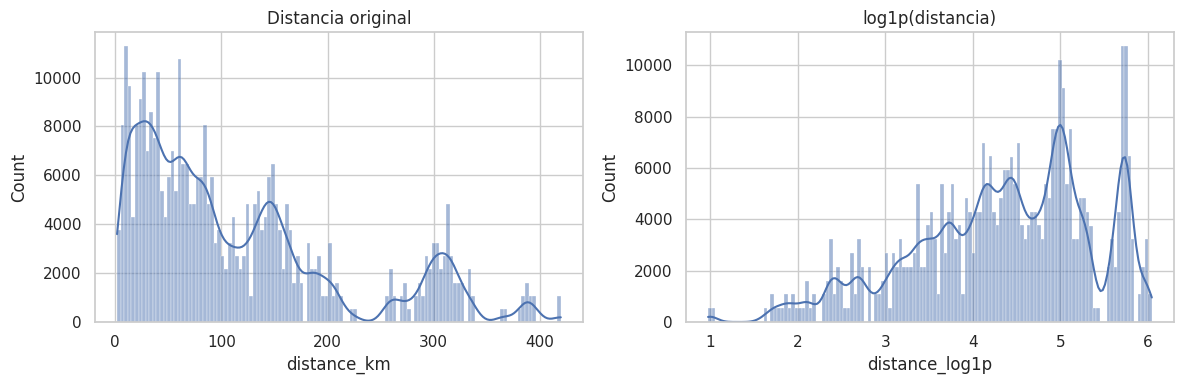

In [7]:
comparison = pd.DataFrame({
    "feature": ["distance_km", "distance_log1p"],
    "skew_train": [
        train_fe["distance_km"].skew(),
        train_fe["distance_log1p"].skew()
    ],
    "corr_target": [
        train_fe["distance_km"].corr(train_fe[TARGET]),
        train_fe["distance_log1p"].corr(train_fe[TARGET])
    ]
})
display(comparison)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(train_fe["distance_km"], kde=True, ax=axes[0])
axes[0].set_title("Distancia original")
sns.histplot(train_fe["distance_log1p"], kde=True, ax=axes[1])
axes[1].set_title("log1p(distancia)")
plt.tight_layout()
plt.show()


## 4. Codificación de variables categoricas

`origin_zone`, `destination_zone` y `distance_bin` son variables nominales/ordinales sin una distancia numerica natural entre categorias. Por ello se utiliza **One-Hot Encoding**, evitando imponer un orden artificial.

El codificador se ajusta solamente con entrenamiento. `handle_unknown="ignore"` permite que una categoria nueva aparezca en prueba/produccion sin romper el pipeline.

En esta fase se integra dentro de un pipeline reproducible junto con las nuevas caracterIsticas.

In [8]:
#categorical_features = ["origin_zone", "destination_zone", "distance_bin"]
categorical_features = [
    "origin_zone_id",
    "destination_zone_id",
    "distance_bin"
]

numeric_features = [
    "distance_km", "distance_log1p",
    "hour_sin", "hour_cos", "dow_sin", "dow_cos",
    "is_weekend", "is_rush_hour"
]

# VerificaciOn
missing_required = [c for c in categorical_features + numeric_features + [TARGET] if c not in train_fe.columns]
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

print("Categóricas:", categorical_features)
print("Numéricas:", numeric_features)


Categóricas: ['origin_zone_id', 'destination_zone_id', 'distance_bin']
Numéricas: ['distance_km', 'distance_log1p', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']


In [9]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(train_fe[categorical_features])
X_test_cat = encoder.transform(test_fe[categorical_features])

encoded_columns = encoder.get_feature_names_out(categorical_features)

X_train_cat = pd.DataFrame(
    X_train_cat,
    columns=encoded_columns,
    index=train_fe.index
)

X_test_cat = pd.DataFrame(
    X_test_cat,
    columns=encoded_columns,
    index=test_fe.index
)

print("Variables categóricas originales:", len(categorical_features))
print("Variables después de One-Hot:", len(encoded_columns))

display(X_train_cat.head())

Variables categóricas originales: 3
Variables después de One-Hot: 58


,origin_zone_id_1.0,origin_zone_id_2.0,origin_zone_id_3.0,origin_zone_id_4.0,origin_zone_id_5.0,origin_zone_id_6.0,origin_zone_id_7.0,origin_zone_id_8.0,origin_zone_id_10.0,origin_zone_id_11.0,origin_zone_id_12.0,origin_zone_id_13.0,origin_zone_id_14.0,origin_zone_id_15.0,origin_zone_id_16.0,origin_zone_id_17.0,origin_zone_id_18.0,origin_zone_id_19.0,origin_zone_id_20.0,origin_zone_id_21.0,origin_zone_id_22.0,origin_zone_id_23.0,origin_zone_id_24.0,origin_zone_id_25.0,origin_zone_id_26.0,origin_zone_id_27.0,origin_zone_id_nan,destination_zone_id_1.0,destination_zone_id_2.0,destination_zone_id_3.0,destination_zone_id_4.0,destination_zone_id_5.0,destination_zone_id_6.0,destination_zone_id_7.0,destination_zone_id_8.0,destination_zone_id_10.0,destination_zone_id_11.0,destination_zone_id_12.0,destination_zone_id_13.0,destination_zone_id_14.0,destination_zone_id_15.0,destination_zone_id_16.0,destination_zone_id_17.0,destination_zone_id_18.0,destination_zone_id_19.0,destination_zone_id_20.0,destination_zone_id_21.0,destination_zone_id_22.0,destination_zone_id_23.0,destination_zone_id_24.0,destination_zone_id_25.0,destination_zone_id_26.0,destination_zone_id_27.0,destination_zone_id_nan,distance_bin_bin_1,distance_bin_bin_2,distance_bin_bin_3,distance_bin_bin_4
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


## 5. Escalamiento

Se utiliza estandarización (`StandardScaler`) para las variables numéricas. Esto centra cada variable en media 0 y desviación estándar 1.

La estandarizacion es especialmente importante antes de PCA, porque PCA depende de la varianza y una variable con unidades o escala mayor podria dominar los componentes.

In [10]:
numeric_scaler = StandardScaler()
X_train_num = numeric_scaler.fit_transform(train_fe[numeric_features])
X_test_num = numeric_scaler.transform(test_fe[numeric_features])

print("Media aproximada de train después de estandarizar:")
print(np.round(X_train_num.mean(axis=0), 4))
print("Desviación estándar aproximada:")
print(np.round(X_train_num.std(axis=0), 4))


Media aproximada de train después de estandarizar:
[-0. -0.  0.  0. -0.  0.  0. -0.]
Desviación estándar aproximada:
[1. 1. 1. 1. 1. 1. 1. 1.]


## 6. Métodos de filtrado para selección de características

Se aplican tres criterios complementarios:

### 6.1 Umbral de varianza
Elimina variables constantes o prácticamente constantes. Una característica sin variabilidad no puede discriminar entre observaciones. Se usa como filtro inicial y no depende de la variable objetivo.

### 6.2 Correlacion entre caracteristicas
Se buscan pares de variables numericas con correlacion absoluta alta (`|r| > 0.90`). El objetivo es reducir redundancia. En particular, `distance_km` y `distance_log1p` pueden contener prácticamente la misma señal.

### 6.3 Informacion mutua con el target
La información mutua permite detectar relaciones potencialmente no lineales entre una característica y la duración. Es apropiada como complemento de la correlación, que solo mide dependencia lineal.

La selección se hace sobre entrenamiento para evitar que información del conjunto de prueba influya en las decisiones de modelado.

In [11]:
# 6.1 Umbral de varianza
binary_and_numeric = numeric_features.copy()
X_var = train_fe[binary_and_numeric].copy()

vt = VarianceThreshold(threshold=0.0)
vt.fit(X_var)

kept_var = X_var.columns[vt.get_support()].tolist()
removed_var = [c for c in X_var.columns if c not in kept_var]

print("Características conservadas por variance threshold:")
print(kept_var)
print("\nCaracterísticas eliminadas por varianza cero:")
print(removed_var if removed_var else "Ninguna")


Características conservadas por variance threshold:
['distance_km', 'distance_log1p', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']

Características eliminadas por varianza cero:
Ninguna


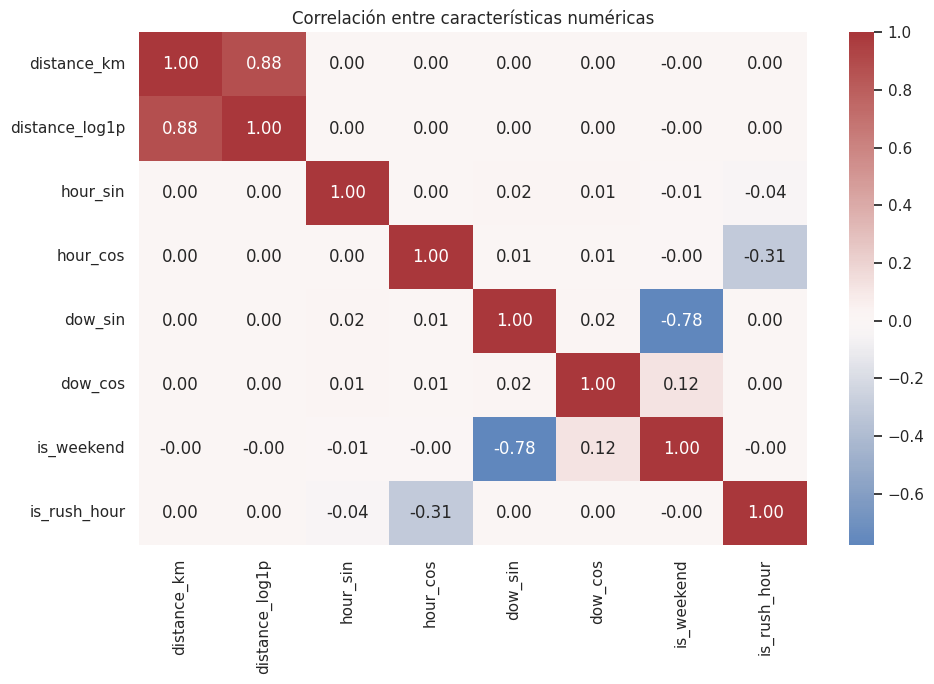

Variables eliminadas por |correlación| > 0.9 :
Ninguna

Variables numéricas después del filtro de correlación:
['distance_km', 'distance_log1p', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_rush_hour']


In [12]:
# 6.2 Correlacion entre variables numéricas
corr = train_fe[kept_var].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlación entre características numéricas")
plt.tight_layout()
plt.show()

threshold_corr = 0.90
to_drop_corr = set()

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        if abs(corr.iloc[i, j]) > threshold_corr:
            a, b = corr.columns[i], corr.columns[j]
            # Conservamos la variable original/interpretable cuando existe
            if a == "distance_log1p" and b == "distance_km":
                to_drop_corr.add(a)
            elif b == "distance_log1p" and a == "distance_km":
                to_drop_corr.add(b)
            else:
                # En otros pares, se elimina la segunda por simplicidad reproducible
                to_drop_corr.add(b)

print("Variables eliminadas por |correlación| >", threshold_corr, ":")
print(sorted(to_drop_corr) if to_drop_corr else "Ninguna")

filtered_numeric = [c for c in kept_var if c not in to_drop_corr]
print("\nVariables numéricas después del filtro de correlación:")
print(filtered_numeric)


,mutual_information
distance_log1p,2.400394
distance_km,2.384854
hour_cos,0.038369
dow_sin,0.032334
hour_sin,0.031303
dow_cos,0.014207
is_weekend,0.004222
is_rush_hour,0.003097


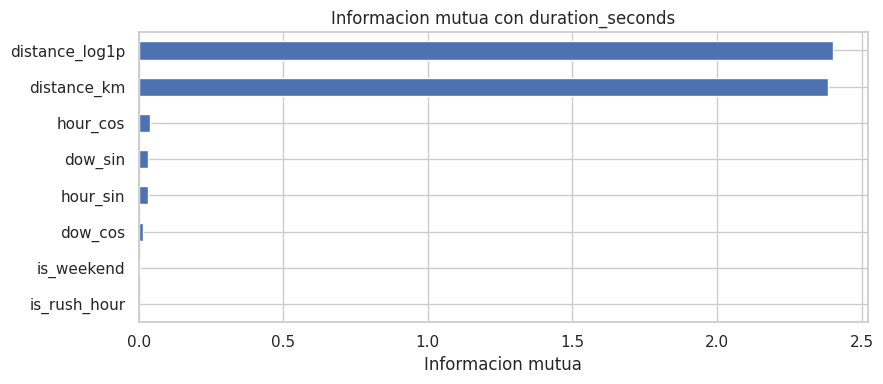

In [13]:
# 6.3 Información mutua con la duración
mi_train = train_fe[filtered_numeric + [TARGET]].dropna()

mi = mutual_info_regression(
    mi_train[filtered_numeric],
    mi_train[TARGET],
    random_state=42
)

mi_result = (
    pd.Series(mi, index=filtered_numeric)
      .sort_values(ascending=False)
      .rename("mutual_information")
)

display(mi_result.to_frame())

plt.figure(figsize=(9, 4))
mi_result.sort_values().plot(kind="barh")
plt.title("Informacion mutua con duration_seconds")
plt.xlabel("Informacion mutua")
plt.tight_layout()
plt.show()


## 7. PCA



# Conclusiones TODOS



## Bibliografía


